In [1]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis

In [2]:
def compute_radial_spectrum(fld,dx,dy,dtype=float,mask=None):
    """
    Compute the radial spectra of a 2D field
    input:
    fld : np.array or any 2D field
    dx : (float)
         grid x resolution
    dy : (float)
         grid y resolution
    """
    (nx,ny) = np.shape(np.asarray(fld))
    x = np.arange(dtype(nx)) * dx
    y = np.arange(dtype(ny)) * dy
    kx = np.fft.fftfreq(nx,d=dx) *2*np.pi 
    ky = np.fft.fftfreq(ny,d=dy) *2*np.pi 
    
    #isotropizing
    aa = np.sqrt(np.repeat(kx[np.newaxis,:]**2,ny,axis=0).transpose() + \
                 np.repeat(ky[np.newaxis,:]**2,nx,axis=0))   
    
    #resolution in k_r
    dk = kx[2] - kx[1]
    nk = np.int64(np.max(aa)/dk  + 1)
    kk = np.arange(dtype(nk)) * dk
    i1 = (aa/dk).astype(np.int64)
    i2 = i1 + 1
    s2 = aa/dk - i1.astype(dtype)
    s1 = 1 - s2
    tags=['kk','sp']
    
 
    sps= np.recarray((nk,),dtype=[(i,dtype) for i in tags])
    sps.kk=kk
    sp = np.zeros(nk,dtype=dtype)
    ff=np.abs(np.fft.ifft2(fld))**2
    #if mask is not None:  
    #    if (np.shape(mask) == ff.shape): 
    #    ff * = np.asarray(mask)
    f1 = ff*s1
    f2 = ff*s2

    for i in range(nx):
        for j in range(ny):
            if i2[i,j] < nk :
                sp[i2[i,j]] += f2[i,j] 
                sp[i1[i,j]] += f1[i,j] 
    sps['sp']=sp/dk
    
    
    return sps

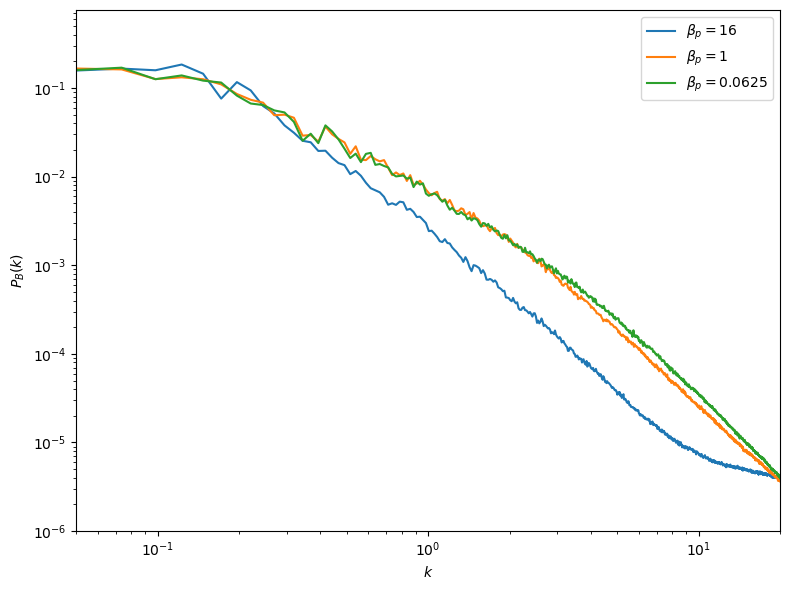

In [18]:
dx = dy = 0.0625
t = 260

cases = {
    r'$\beta_p=16$': '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_16/beta_e_1',
    r'$\beta_p=1$':  '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1',
    r'$\beta_p=0.0625$': '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_0.0625/beta_e_1'
}

plt.figure(figsize=(8, 6))

for label, base_path in cases.items():

    File_Bx = f'{base_path}/Bx_ApJ_t{t}.h5'
    File_By = f'{base_path}/By_ApJ_t{t}.h5'

    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
        data_Bx = fBx['DS1'][:].T
        data_By = fBy['DS1'][:].T

    spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
    spectrum_By = compute_radial_spectrum(data_By, dx, dy)

    spectrum_Bp = np.recarray(spectrum_Bx.shape, dtype=spectrum_Bx.dtype)
    spectrum_Bp.kk = spectrum_Bx.kk
    spectrum_Bp.sp = spectrum_Bx.sp + spectrum_By.sp

    plt.loglog(spectrum_Bp.kk, spectrum_Bp.sp, label=label)

plt.xlabel(r'$k$')
plt.ylabel(r'$P_B(k)$')
plt.xlim(5e-2, 20)
plt.ylim(1e-6, None)
plt.legend()
plt.tight_layout()
plt.savefig("CompareBp_all_beta_p.png", dpi=300)
plt.show()

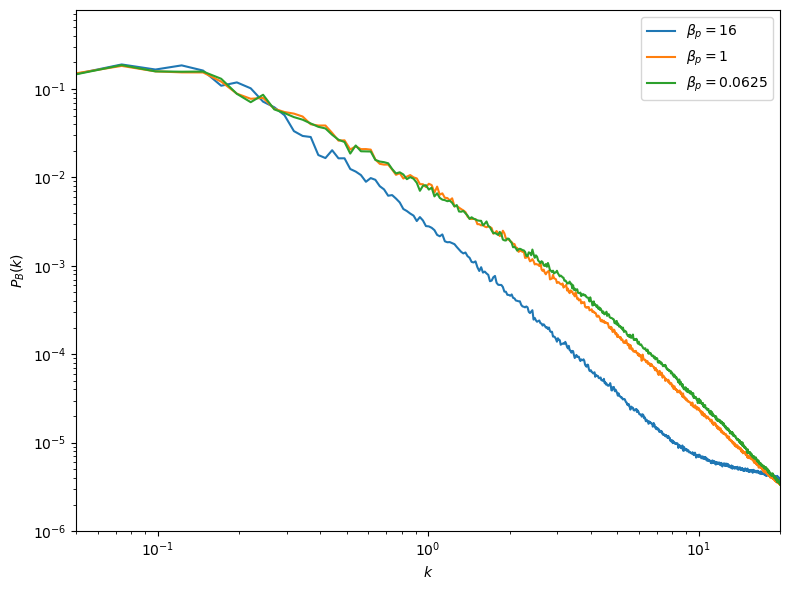

In [5]:
dx = dy = 0.0625

# cases = {
#     r'$\beta_p=16$': {
#         'path': '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_16/beta_e_1',
#         't': 260
#     },
#     r'$\beta_p=1$': {
#         'path': '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1',
#         't': 271
#     },
#     r'$\beta_p=0.0625$': {
#         'path': '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_0.0625/beta_e_1',
#         't': 255
#     }
# }

cases = {
    r'$\beta_p=16$': {
        'path': '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_16/beta_e_1',
        't': 200
    },
    r'$\beta_p=1$': {
        'path': '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1',
        't': 200
    },
    r'$\beta_p=0.0625$': {
        'path': '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_0.0625/beta_e_1',
        't': 200
    }
}


plt.figure(figsize=(8, 6))

for label, cfg in cases.items():

    t = cfg['t']
    base_path = cfg['path']

    File_Bx = f'{base_path}/Bx_ApJ_t{t}.h5'
    File_By = f'{base_path}/By_ApJ_t{t}.h5'

    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
        data_Bx = fBx['DS1'][:].T
        data_By = fBy['DS1'][:].T

    spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
    spectrum_By = compute_radial_spectrum(data_By, dx, dy)

    spectrum_Bp = np.recarray(spectrum_Bx.shape, dtype=spectrum_Bx.dtype)
    spectrum_Bp.kk = spectrum_Bx.kk
    spectrum_Bp.sp = spectrum_Bx.sp + spectrum_By.sp

    plt.loglog(spectrum_Bp.kk, spectrum_Bp.sp,
               label=fr'{label}')

plt.xlabel(r'$k$')
plt.ylabel(r'$P_B(k)$')
plt.xlim(5e-2, 20)
plt.ylim(1e-6, None)
plt.legend()
plt.tight_layout()
plt.savefig("CompareBp_diff_times.png", dpi=300)
plt.show()